## **LSTM**

1.  LSTM stands for Long Short Term Memory.

2.  It is a special type of neural network model used for time series forecasting.

## **Normal Neural Network:**

Input → Hidden Layer → Output

## **LSTM:**

Past Information

       ↓

+----------------+

| Memory Cell    |

+----------------+

       ↓

Prediction


## **Definition:**

1.  LSTM uses the past information and uses them to predict the future values.


## **When to use LSTM ?**

  LSTM is used when

  (i) the data is sequential

  (ii) long term patterns exists

  (iii) large amount of non-linear relationships exists

  (iv)  large amount of historical data is there


##  **Examples:**

  (i)   Stock Price Prediction

  (ii)  Sales Forecasting

  (iii) Weather Forecasting

  (iv)  Demand Forecasting

  (v)   Energy Consumption Forecasting

## **Step 1: Import all the necessary libraries:**

In [1392]:
import  numpy             as  np
import  pandas            as  pd
import  matplotlib.pyplot as  plt
import  seaborn           as  sns

from    sklearn.preprocessing import  MinMaxScaler
from    sklearn.model_selection import  train_test_split

from    tensorflow.keras.models import  Sequential
from    tensorflow.keras.layers import  LSTM
from    tensorflow.keras.layers import  Dense

## **OBSERVATIONS:**

(i) MinMaxScaler ==============> used for normalizing the data

(ii) Sequential  ==============> used for creating a sequential model

(iii) LSTM ====================> helps in creating the LSTM layer for padding sequences

(iv)  Dense ===================> helps in creating the dense output layer.

## **Step 2: Load the dataset:**

In [1393]:
#### Load the dataset

df = pd.read_csv('/content/AirPassengers.csv')

In [1394]:
df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


## **OBSERVATIONS:**

1.The above dataset represents the airline passengers data for the starting date of each month from 1949 till 1960.

## **Step 3: Perform the Data Exploration:**

In [1395]:
### get the first five rows of the dataset

df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [1396]:
### get the last five rows of the dataset

df.tail()

,date,value
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


In [1397]:
### get the length of the dataset

print('Length of the dataset is:', len(df))

Length of the dataset is: 144


In [1398]:
### get the shape of the dataset

print('Shape of the dataset is:', df.shape)

Shape of the dataset is: (144, 2)


In [1399]:
### get the columns in the dataset

df.columns

Index(['date', 'value'], dtype='object')

In [1400]:
### get the information about the columns in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   value   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


## **OBSERVATIONS:**

1.  The data type of date is of 'object' type.

In [1401]:
#### get the descriptive statistics about the numerical columns in the dataset

df.describe()

,value
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [1402]:
#### get the descriptive statistics about the categorical columns in the dataset

df.describe(include='object')

,date
count,144
unique,144
top,1949-01-01
freq,1


## **Step 4: Perform Data Cleaning and Feature Engineering**

In [1403]:
### To rename the column name 'value' to 'Passengers' in the dataset

df.rename(columns={'value':'Passengers'},inplace=True)

In [1404]:
df

,date,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


## **OBSERVATIONS:**

1. The column name 'value' has been chnages to 'Passengers' in the dataset.

In [1405]:
### To make the 'date' column as an index
df.set_index('date', inplace=True)

## **OBSERVATIONS:**

1.  The date column has been made as an index.

In [1406]:
### To check for the NULL records in the dataset

df.isnull().sum()

,0
Passengers,0


## **OBSERVATIONS:**

1.  There are no NULL records in the dataset.

In [1407]:
### To check for the duplicate records in the dataset

df[df.duplicated()]

,Passengers
date,
1949-08-01,148
1949-12-01,118
1950-04-01,135
1950-08-01,170
1951-06-01,178
1951-08-01,199
1952-11-01,172
1953-02-01,196
1953-11-01,180


In [1408]:
### Drop the duplicate records from the dataset

df.drop_duplicates(inplace=True)

In [1409]:
### To again check for the duplicate records in the dataset

df[df.duplicated()]

,Passengers
date,


## **OBSERVATIONS:**

1.  There are no duplicate records in the dataset.

## **Step 5: Plot the original time series data**

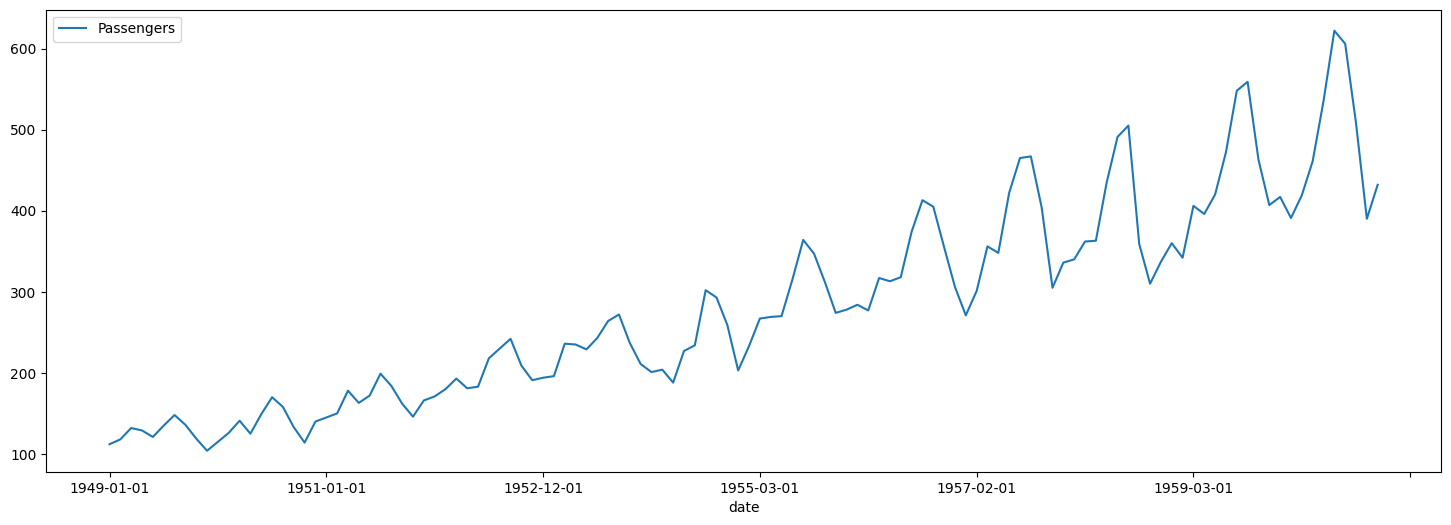

In [1410]:
### plot the time series
df.plot(figsize=(18,6))
plt.show()

## **OBSERVATIONS:**

1.  The above dataset represents the increasing upward trend in the Passengers data from 1949 till 1960 for the starting date of each month.

2. The time series is non-stationary in nature.

3. So it is concluded that seasonality also exists in the data.

## **Step 6: Perform Feature Scaling**

In [1411]:
from  sklearn.preprocessing import  MinMaxScaler

### create an object for MinMaxScaler

scaler = MinMaxScaler()

### using the object for MinMaxScaler, transform the dataframe

scaled_data = scaler.fit_transform(df)

In [1412]:
scaled_data

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853],
       [0.05984556],
       [0.08494208],
       [0.06177606],
       [0.02895753],
       [0.        ],
       [0.02123552],
       [0.04247104],
       [0.07142857],
       [0.04054054],
       [0.08687259],
       [0.12741313],
       [0.1042471 ],
       [0.05598456],
       [0.01930502],
       [0.06949807],
       [0.07915058],
       [0.08880309],
       [0.14285714],
       [0.11389961],
       [0.13127413],
       [0.18339768],
       [0.15444015],
       [0.11196911],
       [0.08108108],
       [0.11969112],
       [0.12934363],
       [0.14671815],
       [0.17181467],
       [0.14864865],
       [0.15250965],
       [0.22007722],
       [0.24324324],
       [0.26640927],
       [0.2027027 ],
       [0.16795367],
       [0.17374517],
       [0.17760618],
       [0.25482625],
       [0.25289575],
       [0.24131274],
       [0.26833977],
       [0.30888031],
       [0.324

## **OBSERVATIONS:**

1. MinMaxScaler is the scaling technique used for scaling the values used for the neural network model.

2. It helps in scaling the values in the range between 0 to 1.

## **Step 7: Divide the dataset into training and testing data**

In [1413]:
### determine the train size
train_size = int(len(scaled_data)*0.8)

### divide the dataset into training and testing data
train = scaled_data[:train_size]
test  = scaled_data[train_size:]

In [1414]:
print("Shape of the training data is:", train.shape)
print("Shape of the testing  data is:", test.shape)

Shape of the training data is: (94, 1)
Shape of the testing  data is: (24, 1)


## **OBSERVATIONS:**

1. 94 records are for the training and 24 records are for the testing purpose.

In [1415]:
train

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853],
       [0.05984556],
       [0.08494208],
       [0.06177606],
       [0.02895753],
       [0.        ],
       [0.02123552],
       [0.04247104],
       [0.07142857],
       [0.04054054],
       [0.08687259],
       [0.12741313],
       [0.1042471 ],
       [0.05598456],
       [0.01930502],
       [0.06949807],
       [0.07915058],
       [0.08880309],
       [0.14285714],
       [0.11389961],
       [0.13127413],
       [0.18339768],
       [0.15444015],
       [0.11196911],
       [0.08108108],
       [0.11969112],
       [0.12934363],
       [0.14671815],
       [0.17181467],
       [0.14864865],
       [0.15250965],
       [0.22007722],
       [0.24324324],
       [0.26640927],
       [0.2027027 ],
       [0.16795367],
       [0.17374517],
       [0.17760618],
       [0.25482625],
       [0.25289575],
       [0.24131274],
       [0.26833977],
       [0.30888031],
       [0.324

In [1416]:
test

array([[0.77413127],
       [0.49227799],
       [0.3976834 ],
       [0.44980695],
       [0.49420849],
       [0.45945946],
       [0.58301158],
       [0.56370656],
       [0.61003861],
       [0.71042471],
       [0.85714286],
       [0.87837838],
       [0.69305019],
       [0.58494208],
       [0.6042471 ],
       [0.55405405],
       [0.60810811],
       [0.68918919],
       [0.83204633],
       [1.        ],
       [0.96911197],
       [0.77992278],
       [0.55212355],
       [0.63320463]])

## **Step 8: Create the Sequence:**

In [1417]:
def create_dataset(data, time_step=12):

    X = []
    y = []

    for i in range(len(data)-time_step):

        X.append(data[i:(i+time_step),0])
        y.append(data[i+time_step,0])

    return np.array(X), np.array(y)

## **OBSERVATIONS:**

1.  LSTM performs the future predictions based on the past sequences of the data.

2.  If we fed each data directly into the model without creating the sequence, then the model will consider each value independently without considering the order of sequence of observations.

3.  Then the LSTM model will not accuratly forecast the value as the LSTM model will forecast the predictions based on the past observations.

## **Step 9: Create Training Data and Testing Data**

In [1418]:
### Training data
X_train, Y_train = create_dataset(train,12)

### Testing data
X_test, Y_test   = create_dataset(test,12)

In [1419]:
X_train

array([[0.01544402, 0.02702703, 0.05405405, 0.04826255, 0.03281853,
        0.05984556, 0.08494208, 0.06177606, 0.02895753, 0.        ,
        0.02123552, 0.04247104],
       [0.02702703, 0.05405405, 0.04826255, 0.03281853, 0.05984556,
        0.08494208, 0.06177606, 0.02895753, 0.        , 0.02123552,
        0.04247104, 0.07142857],
       [0.05405405, 0.04826255, 0.03281853, 0.05984556, 0.08494208,
        0.06177606, 0.02895753, 0.        , 0.02123552, 0.04247104,
        0.07142857, 0.04054054],
       [0.04826255, 0.03281853, 0.05984556, 0.08494208, 0.06177606,
        0.02895753, 0.        , 0.02123552, 0.04247104, 0.07142857,
        0.04054054, 0.08687259],
       [0.03281853, 0.05984556, 0.08494208, 0.06177606, 0.02895753,
        0.        , 0.02123552, 0.04247104, 0.07142857, 0.04054054,
        0.08687259, 0.12741313],
       [0.05984556, 0.08494208, 0.06177606, 0.02895753, 0.        ,
        0.02123552, 0.04247104, 0.07142857, 0.04054054, 0.08687259,
        0.12741313,

In [1420]:
Y_train

array([0.07142857, 0.04054054, 0.08687259, 0.12741313, 0.1042471 ,
       0.05598456, 0.01930502, 0.06949807, 0.07915058, 0.08880309,
       0.14285714, 0.11389961, 0.13127413, 0.18339768, 0.15444015,
       0.11196911, 0.08108108, 0.11969112, 0.12934363, 0.14671815,
       0.17181467, 0.14864865, 0.15250965, 0.22007722, 0.24324324,
       0.26640927, 0.2027027 , 0.16795367, 0.17374517, 0.17760618,
       0.25482625, 0.25289575, 0.24131274, 0.26833977, 0.30888031,
       0.32432432, 0.25675676, 0.20656371, 0.18725869, 0.19305019,
       0.16216216, 0.23745174, 0.25096525, 0.38223938, 0.36486486,
       0.2992278 , 0.19111969, 0.24903475, 0.31467181, 0.31853282,
       0.32046332, 0.40733591, 0.5019305 , 0.46911197, 0.4015444 ,
       0.32818533, 0.33590734, 0.34749035, 0.33397683, 0.41119691,
       0.4034749 , 0.41312741, 0.52123552, 0.5965251 , 0.58108108,
       0.48455598, 0.38996139, 0.32239382, 0.38030888, 0.48648649,
       0.47104247, 0.61389961, 0.6969112 , 0.7007722 , 0.57915

## **OBSERVATIONS:**

1. Here the input training and testing data are created in sequence rather than the individual data as

  (a.)  LSTM considers the data in sequential time series form not as the individual format and thus the inputs are produced in sequence.

## **Step 10: Check Shape**

In [1421]:
print("Shape of the input training data is:", X_train.shape)

print("Shape of the input testing data is:", X_test.shape)

Shape of the input training data is: (82, 12)
Shape of the input testing data is: (12, 12)


In [1422]:
print("Shape of the output training data is:", Y_train.shape)

print("Shape of the output testing data is:", Y_test.shape)

Shape of the output training data is: (82,)
Shape of the output testing data is: (12,)


## **Step 11: Reshape the Input**

In [1423]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1],1)

In [1424]:
X_train

array([[[0.01544402],
        [0.02702703],
        [0.05405405],
        [0.04826255],
        [0.03281853],
        [0.05984556],
        [0.08494208],
        [0.06177606],
        [0.02895753],
        [0.        ],
        [0.02123552],
        [0.04247104]],

       [[0.02702703],
        [0.05405405],
        [0.04826255],
        [0.03281853],
        [0.05984556],
        [0.08494208],
        [0.06177606],
        [0.02895753],
        [0.        ],
        [0.02123552],
        [0.04247104],
        [0.07142857]],

       [[0.05405405],
        [0.04826255],
        [0.03281853],
        [0.05984556],
        [0.08494208],
        [0.06177606],
        [0.02895753],
        [0.        ],
        [0.02123552],
        [0.04247104],
        [0.07142857],
        [0.04054054]],

       [[0.04826255],
        [0.03281853],
        [0.05984556],
        [0.08494208],
        [0.06177606],
        [0.02895753],
        [0.        ],
        [0.02123552],
        [0.04247104],
    

In [1425]:
print("Shape of the refined input training data:", X_train.shape)

Shape of the refined input training data: (82, 12, 1)


In [1426]:
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1],1)

In [1427]:
X_test

array([[[0.77413127],
        [0.49227799],
        [0.3976834 ],
        [0.44980695],
        [0.49420849],
        [0.45945946],
        [0.58301158],
        [0.56370656],
        [0.61003861],
        [0.71042471],
        [0.85714286],
        [0.87837838]],

       [[0.49227799],
        [0.3976834 ],
        [0.44980695],
        [0.49420849],
        [0.45945946],
        [0.58301158],
        [0.56370656],
        [0.61003861],
        [0.71042471],
        [0.85714286],
        [0.87837838],
        [0.69305019]],

       [[0.3976834 ],
        [0.44980695],
        [0.49420849],
        [0.45945946],
        [0.58301158],
        [0.56370656],
        [0.61003861],
        [0.71042471],
        [0.85714286],
        [0.87837838],
        [0.69305019],
        [0.58494208]],

       [[0.44980695],
        [0.49420849],
        [0.45945946],
        [0.58301158],
        [0.56370656],
        [0.61003861],
        [0.71042471],
        [0.85714286],
        [0.87837838],
    

In [1428]:
print("Shape of the refined input testing data:", X_test.shape)

Shape of the refined input testing data: (12, 12, 1)


## **OBSERVATIONS:**

1.  LSTM considers the input in 3D form i.e
    (samples, timestamps, features)

2.  But the input training and testing data is in 2D form.

3.  So reshaping is done to convert the 2D input feature into 3D input feature.

## **Step 12: Create the LSTM Model**

In [1429]:
### Create a Sequential Model
model = Sequential()

### Create a LSTM layer inside the sequential model
model.add(LSTM(50, activation = 'relu', input_shape=(12,1)))

### Create an output layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## **OBSERVATIONS:**

1. A sequential model is created.

2.  A LSTM layer has been created inside the sequential model that has the following parameters:---

(a.)  Input =========>  past 12 observations

(b.)  activation =====> 'Relu' to increase the non-linearity of the data

(c.)  50 neurons have been created in this layer.


## **Step 13: Compile the model**

In [1430]:
### Compile the model
model.compile(
    optimizer = 'adam'        ,
    loss      =  'mse'
)

## **OSBERVATIONS:**

1.  The model has been made ready for training with the help of following parameters:----

    (a.)  optimizer = 'adam' ====> Adam optimizer automatically updates the weights.

    (b.)  loss = 'mse' ========> Mean Squared Error as the output value is a continuous value.

## **Step 14: Train the model**

In [1431]:
### Train the model

history = model.fit(
    X_train,
    Y_train,
    epochs = 100,
    batch_size = 16,
    validation_split = 0.2,
    validation_data = (X_test, Y_test),
    verbose = 1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.1220 - val_loss: 0.4625
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0842 - val_loss: 0.3320
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0535 - val_loss: 0.2162
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0295 - val_loss: 0.1099
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0139 - val_loss: 0.0370
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0118 - val_loss: 0.0203
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0136 - val_loss: 0.0212
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0096 - val_loss: 0.0347
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0090 - val_loss: 0.0456
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0095 - val_loss: 0.0325
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0074 - val_loss: 0.0213
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0069 - val_lo

## **OBSERVATIONS:**

1. The model has been trained with the following parameters :-----------

(a.)  Training = X_train, Y_train ===> Training data

(b.)   epochs = 100 =======> 100 times training will be done

(c.)  batch_size = 16 inputs will be taken at once.

(d.)  validation_split = 0.2 =====> 20 % validation will be taken

(e.)  validation_data = (X_test, Y_test) ===> Test data

(f.)  verbose = 1 ========> 1 loop and 1 metric for each epoch.

## **Step 15: Predict the Model**

In [1432]:
train_predict=model.predict(X_train)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


In [1433]:
test_predict=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [1434]:
train_predict

array([[0.05808734],
       [0.06392484],
       [0.0646271 ],
       [0.06855956],
       [0.0753598 ],
       [0.08022054],
       [0.0773995 ],
       [0.07078679],
       [0.07267695],
       [0.0771102 ],
       [0.08407172],
       [0.09525587],
       [0.10005534],
       [0.10442898],
       [0.11616696],
       [0.11977234],
       [0.11684866],
       [0.11336225],
       [0.11880486],
       [0.12758642],
       [0.13492046],
       [0.1437501 ],
       [0.14775647],
       [0.1478877 ],
       [0.1576455 ],
       [0.16766559],
       [0.1749531 ],
       [0.17558491],
       [0.1772432 ],
       [0.18396121],
       [0.18916138],
       [0.2034115 ],
       [0.21396473],
       [0.22001289],
       [0.23114571],
       [0.24614711],
       [0.25332755],
       [0.24921463],
       [0.23956122],
       [0.23648886],
       [0.23984198],
       [0.24069957],
       [0.2526122 ],
       [0.25681612],
       [0.27663186],
       [0.28624395],
       [0.28115886],
       [0.258

In [1435]:
test_predict

array([[0.63021976],
       [0.60218066],
       [0.6056501 ],
       [0.63784134],
       [0.66706395],
       [0.7087256 ],
       [0.7637522 ],
       [0.81417423],
       [0.86750764],
       [0.88217413],
       [0.83915573],
       [0.76087624]], dtype=float32)

## OBSERVATIONS:

1. We have the predicted training and testing data in the scaled form.

## **Step 16: Reverse the Scaling**

In [1436]:
### Convert the scaled values back to the original passengers values

train_predict = scaler.inverse_transform(train_predict)

test_predict = scaler.inverse_transform(test_predict)


### Output values

Y_train=scaler.inverse_transform(Y_train.reshape(-1,1))
Y_test=scaler.inverse_transform(Y_test.reshape(-1,1))

In [1437]:
train_predict

array([[134.08925],
       [137.11307],
       [137.47684],
       [139.51385],
       [143.03638],
       [145.55424],
       [144.09294],
       [140.66756],
       [141.64667],
       [143.94308],
       [147.54915],
       [153.34254],
       [155.82866],
       [158.09421],
       [164.1745 ],
       [166.04207],
       [164.52762],
       [162.72165],
       [165.54092],
       [170.08977],
       [173.88881],
       [178.46255],
       [180.53786],
       [180.60583],
       [185.66037],
       [190.85078],
       [194.6257 ],
       [194.95299],
       [195.81198],
       [199.2919 ],
       [201.9856 ],
       [209.36717],
       [214.83372],
       [217.96667],
       [223.73347],
       [231.50421],
       [235.22366],
       [233.09319],
       [228.09271],
       [226.50124],
       [228.23816],
       [228.68239],
       [234.85312],
       [237.03075],
       [247.2953 ],
       [252.27437],
       [249.64029],
       [238.14555],
       [233.86374],
       [238.73643],


In [1438]:
test_predict

array([[430.45386],
       [415.9296 ],
       [417.72678],
       [434.40182],
       [449.53915],
       [471.11987],
       [499.62366],
       [525.74225],
       [553.36896],
       [560.9662 ],
       [538.6827 ],
       [498.1339 ]], dtype=float32)

In [1439]:
Y_train

array([[141.],
       [125.],
       [149.],
       [170.],
       [158.],
       [133.],
       [114.],
       [140.],
       [145.],
       [150.],
       [178.],
       [163.],
       [172.],
       [199.],
       [184.],
       [162.],
       [146.],
       [166.],
       [171.],
       [180.],
       [193.],
       [181.],
       [183.],
       [218.],
       [230.],
       [242.],
       [209.],
       [191.],
       [194.],
       [196.],
       [236.],
       [235.],
       [229.],
       [243.],
       [264.],
       [272.],
       [237.],
       [211.],
       [201.],
       [204.],
       [188.],
       [227.],
       [234.],
       [302.],
       [293.],
       [259.],
       [203.],
       [233.],
       [267.],
       [269.],
       [270.],
       [315.],
       [364.],
       [347.],
       [312.],
       [274.],
       [278.],
       [284.],
       [277.],
       [317.],
       [313.],
       [318.],
       [374.],
       [413.],
       [405.],
       [355.],
       [30

In [1440]:
Y_test

array([[463.],
       [407.],
       [417.],
       [391.],
       [419.],
       [461.],
       [535.],
       [622.],
       [606.],
       [508.],
       [390.],
       [432.]])

## **OBSERVATIONS:**

1. All the scaled values have been converted back into the original passengers data.

## **Step 17: Calculate the RMSE:**

In [1441]:
from sklearn.metrics import mean_squared_error

train_rmse = np.sqrt(mean_squared_error(Y_train, train_predict))
test_rmse  = np.sqrt(mean_squared_error(Y_test, test_predict))

In [1442]:
print("RMSE Value is:", test_rmse)

RMSE Value is: 62.337124005654594


## **OBSERVATIONS:**

1. Prediction error ≈ 79 passengers

## **Step 18: Plot the Actual vs Predicted data**

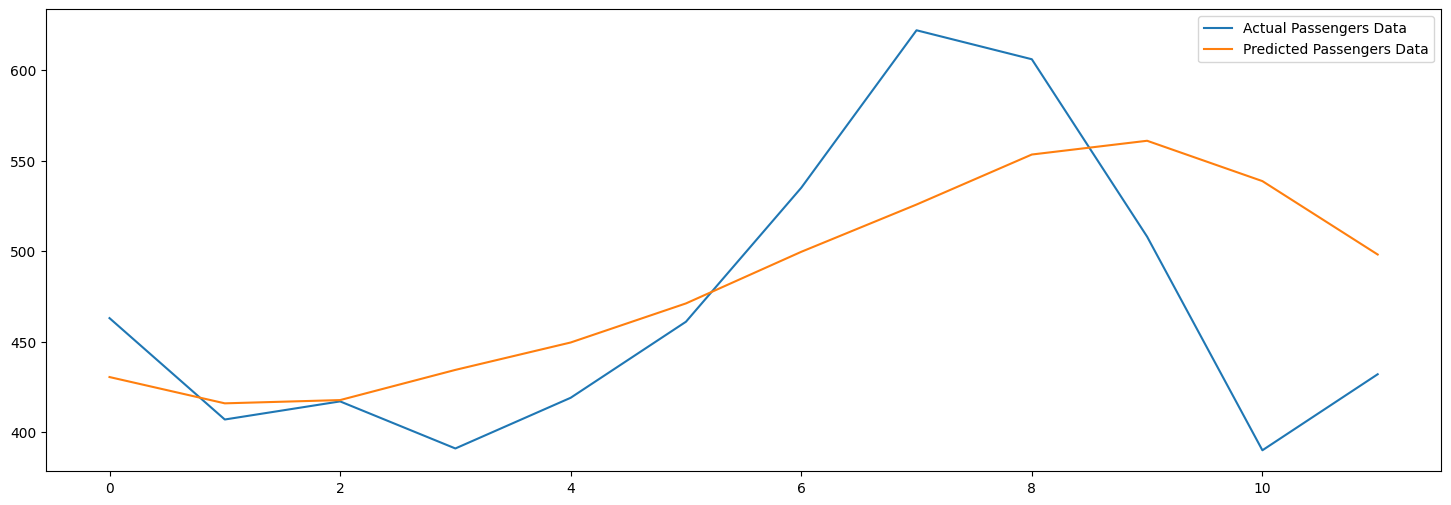

In [1443]:
plt.figure(figsize=(18,6))

### plot the actual passengers data
plt.plot(Y_test, label = 'Actual Passengers Data')

### plot the predicted passengers data
plt.plot(test_predict, label = 'Predicted Passengers Data')

plt.legend()

### display the data
plt.show()

## **OBSERVATIONS:**

1.  The LSTM model successfully captures the upward trend and seasonal movement in passenger counts.

## **Step 19: Forecast Next 12 Months**

In [1444]:
### define the test data
x_input = test[-12:].flatten()

### convert the data into the list
test_input = x_input.tolist()

### create the empty list for forecast
forecast = []

### forecast the values for the next 12 months
for i in range(12):
  ### convert the testing input into numpy array
  x = np.array(test_input[-12:])
  ### reshape the input to appropriate size
  x = x.reshape(1,12,1)
  ### predict the model
  yhat = model.predict(x, verbose=0)
  ### append the values of test_input
  test_input.append(yhat[0][0])
  ### append the value of the forecast
  forecast.append(yhat[0][0])

In [1445]:
test_input

[0.693050193050193,
 0.5849420849420849,
 0.6042471042471043,
 0.5540540540540541,
 0.6081081081081081,
 0.6891891891891891,
 0.832046332046332,
 1.0,
 0.9691119691119692,
 0.7799227799227799,
 0.5521235521235521,
 0.6332046332046332,
 np.float32(0.7434317),
 np.float32(0.7878963),
 np.float32(0.8466154),
 np.float32(0.9016807),
 np.float32(0.96440756),
 np.float32(1.0095363),
 np.float32(1.0240105),
 np.float32(0.98562694),
 np.float32(0.94288075),
 np.float32(0.93972373),
 np.float32(0.97709876),
 np.float32(1.0582194)]

In [1446]:
forecast

[np.float32(0.7434317),
 np.float32(0.7878963),
 np.float32(0.8466154),
 np.float32(0.9016807),
 np.float32(0.96440756),
 np.float32(1.0095363),
 np.float32(1.0240105),
 np.float32(0.98562694),
 np.float32(0.94288075),
 np.float32(0.93972373),
 np.float32(0.97709876),
 np.float32(1.0582194)]

## **OBSERVATIONS:**

1.  The model has forecasted the values for the next 12 months.

2.  The forecasted values are in scalar form so we need to convert it back to original form.

## **Step 20: Convert Forecast Back**

In [1447]:
### Convert the forecasted vaues back to original form
forecast=scaler.inverse_transform(np.array(forecast).reshape(-1,1))

In [1448]:
forecast

array([[489.09763],
       [512.1303 ],
       [542.54675],
       [571.0706 ],
       [603.5631 ],
       [626.93976],
       [634.43744],
       [614.55475],
       [592.41223],
       [590.77686],
       [610.13715],
       [652.15765]], dtype=float32)

## **OBSERVATIONS:**

1.  The forecasted values in the scalar form has been converted back into the original form.

## **Step 21: Plot the Future Forecasted values**

In [1449]:
df

,Passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-07-01,622
1960-08-01,606
1960-09-01,508


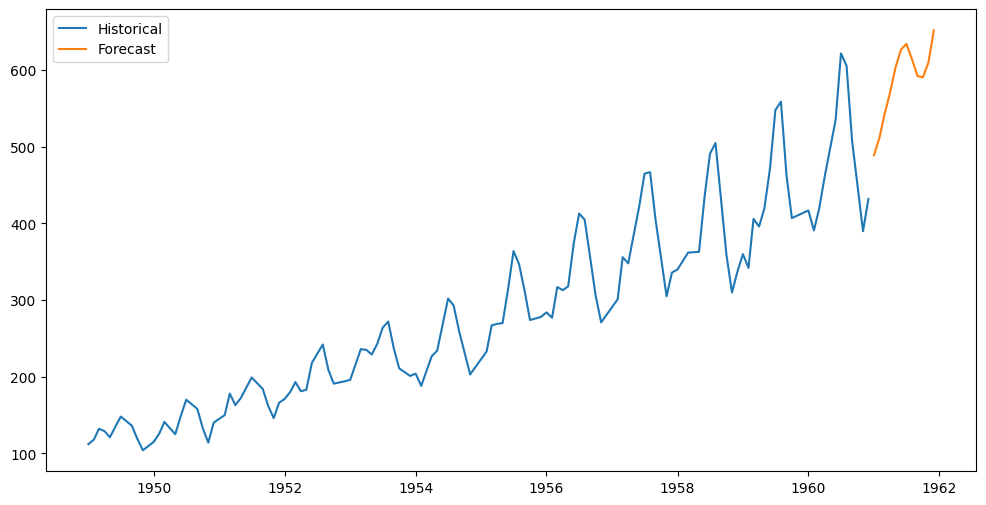

In [1450]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# Ensure forecast is 1D
forecast = np.array(forecast).flatten()

# Create future dates
future_dates = pd.date_range(
    start=df.index.max(),
    periods=len(forecast)+1,
    freq='MS'
)[1:]

# Completely new figure
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    pd.to_datetime(df.index),
    df['Passengers'].values,
    label='Historical'
)

ax.plot(
    future_dates.to_pydatetime(),
    forecast,
    label='Forecast'
)

ax.legend()

plt.show()

## **OBSERVATIONS:**

1.  The forecasted data has followed the same upward trend and the seasonality as the original data.

2.  So it is concluded that LSTM  model uses the past observations and based on it, it predicts the future observations.